In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [3]:
df.head()

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [4]:
mexico = df[(df["entity"] == "Mexico")]
japon = df[(df["entity"] == "Japan")]

In [5]:
mexico.shape



(74, 4)

In [6]:
japon.shape

(77, 4)

In [7]:
type(mexico)

pandas.DataFrame

In [8]:
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [9]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [10]:
type(tasa_mexico)

numpy.ndarray

In [11]:
type(mexico)

pandas.DataFrame

In [12]:
type(anios_mexico)

numpy.ndarray

In [13]:
type(mexico["year"])

pandas.Series

In [14]:
tasa_mexico.shape

(74,)

In [15]:
#Estadísticos tasa México
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

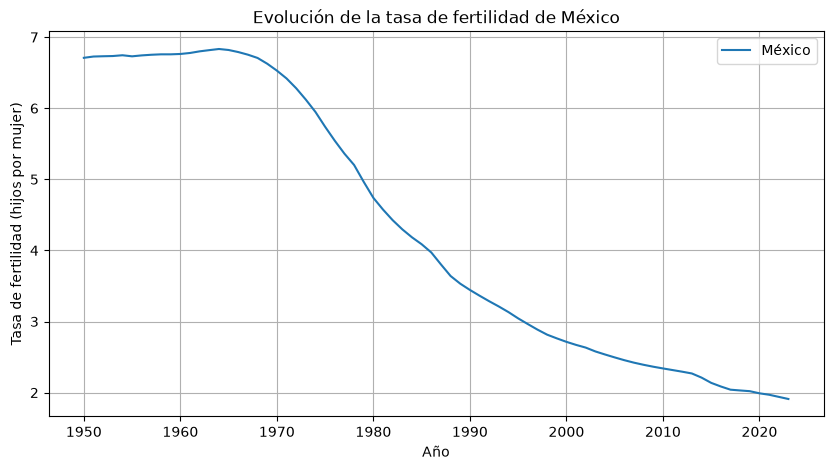

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)
plt.title("Evolución de la tasa de fertilidad de México")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")
plt.grid(True)
plt.legend()
plt.show()

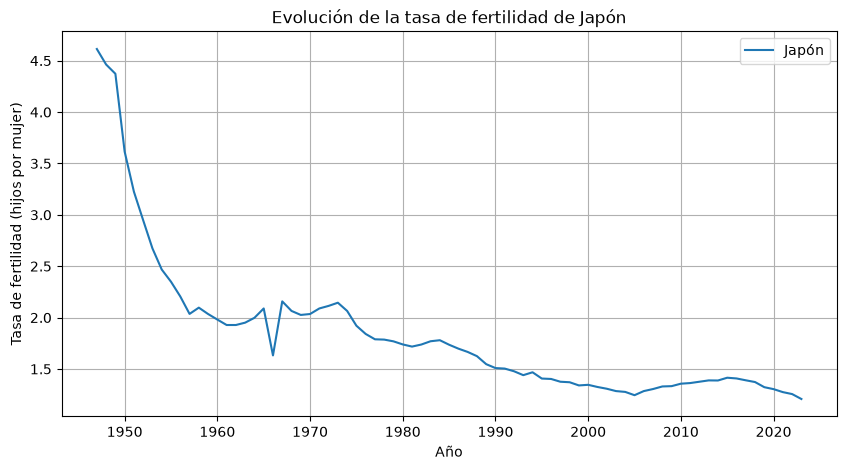

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.title("Evolución de la tasa de fertilidad de Japón")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")
plt.grid(True)
plt.legend()
plt.show()

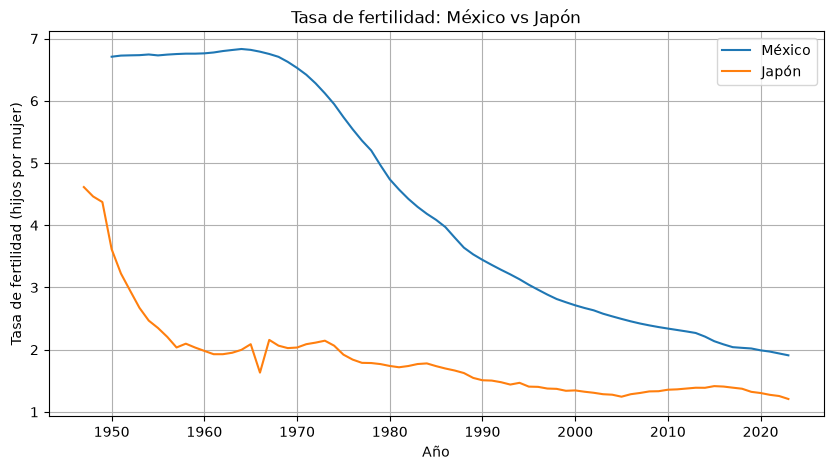

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.title("Tasa de fertilidad: México vs Japón")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")
plt.grid(True)
plt.legend()
plt.show()

In [19]:
mexico.shape

(74, 4)

In [20]:
japon.shape

(77, 4)

In [21]:
print(anios_mexico[0])

1950


In [22]:
print(anios_japon[0])

1947


In [23]:
#Filtro por indexiacion booleana
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [24]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [25]:
anios_japon = anios_japon[mascara_coincidencia_anios]

In [26]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [27]:
anios_mexico.shape

(74,)

In [28]:
anios_japon.shape

(74,)

In [29]:
diferencia_mx_jp = tasa_mexico - tasa_japon

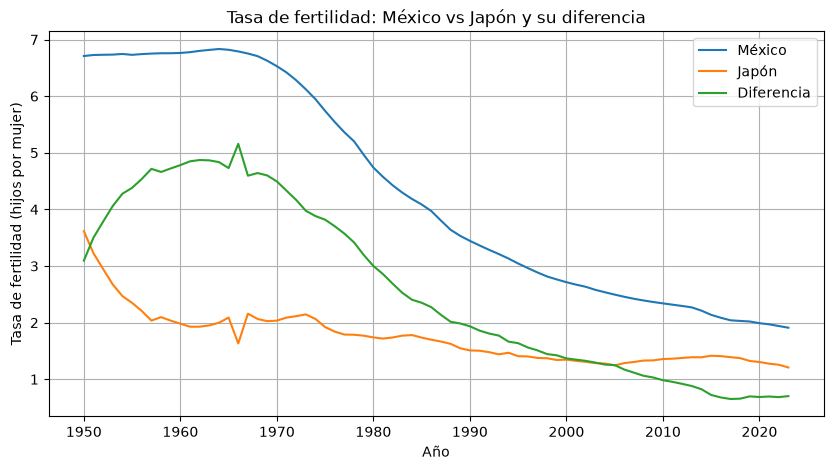

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.plot(
    anios_japon,
    diferencia_mx_jp,
    label="Diferencia"
)
plt.title("Tasa de fertilidad: México vs Japón y su diferencia")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")
plt.grid(True)
plt.legend()
plt.show()

In [31]:
len(tasa_japon)

74

In [32]:
# Años que aparecen en los dos países
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [33]:
len(anios_comunes)

74

In [34]:
type(anios_comunes)

numpy.ndarray

In [35]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]

In [36]:
mexico_anios_comunes.head(3)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731


In [37]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy()
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()

In [38]:
print(mex_anios_comunes)

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023]


In [39]:
print(mex_tasa_comunes)

[6.709 6.727 6.731 6.734 6.745 6.73  6.743 6.752 6.758 6.758 6.763 6.777
 6.8   6.817 6.833 6.819 6.79  6.753 6.707 6.626 6.529 6.419 6.281 6.121
 5.947 5.739 5.543 5.361 5.202 4.964 4.739 4.574 4.425 4.296 4.184 4.087
 3.971 3.803 3.64  3.532 3.444 3.363 3.285 3.211 3.132 3.044 2.964 2.886
 2.815 2.763 2.714 2.671 2.633 2.579 2.536 2.495 2.456 2.421 2.391 2.364
 2.34  2.317 2.294 2.269 2.211 2.137 2.086 2.041 2.03  2.02  1.99  1.97
 1.94  1.91 ]


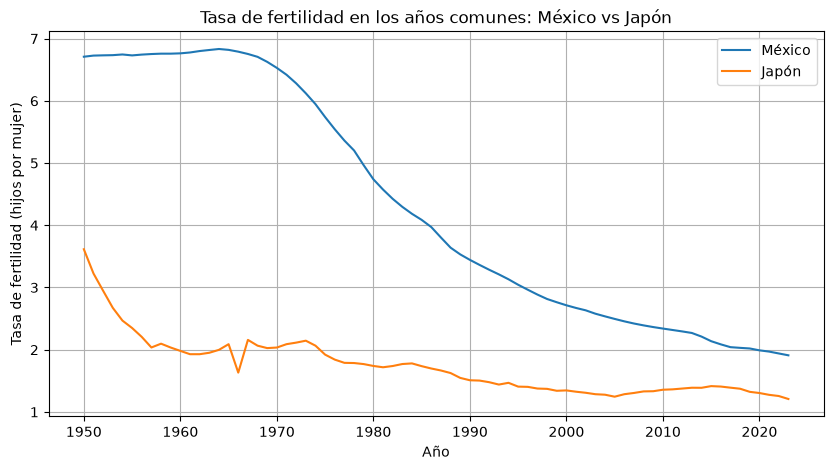

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(
    mex_anios_comunes,
    mex_tasa_comunes,
    label="México"
)
plt.plot(
    jpn_anios_comunes,
    jpn_tasa_comunes,
    label="Japón"
)
plt.title("Tasa de fertilidad en los años comunes: México vs Japón")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad (hijos por mujer)")
plt.grid(True)
plt.legend()
plt.show()

In [41]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")

)

In [42]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [43]:
comparacion_mexico_japon["diferencia"]=(
    comparacion_mexico_japon["fertility_rate_hist_mexico"]
    - comparacion_mexico_japon["fertility_rate_hist_japon"]
)

In [44]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon,diferencia
0,1950,6.709,3.615,3.094
1,1951,6.727,3.225,3.502
2,1952,6.731,2.947,3.784


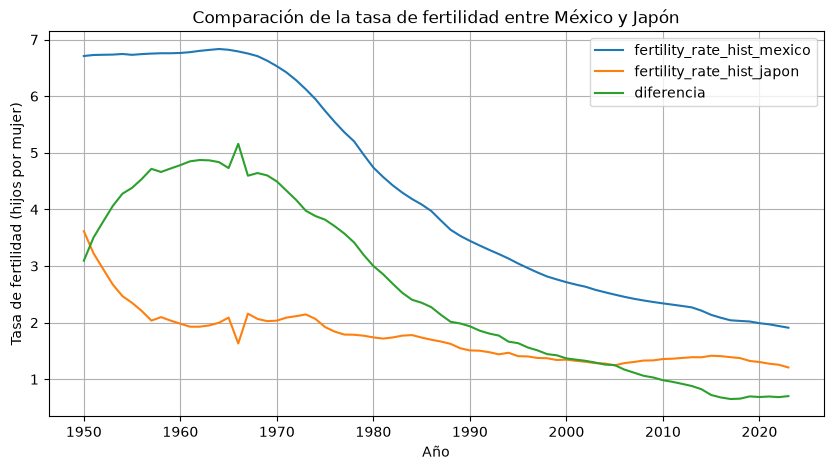

In [45]:
ax = comparacion_mexico_japon.plot(
    x="year",
    y=["fertility_rate_hist_mexico", "fertility_rate_hist_japon", "diferencia"],
    kind="line",
    figsize=(10, 5)
)

ax.set_xlabel("Año")
ax.set_ylabel("Tasa de fertilidad (hijos por mujer)")
ax.set_title("Comparación de la tasa de fertilidad entre México y Japón")
ax.grid(True)
plt.show()